# ATL08 fires: repeat cycles pre- and post-fire

In [1]:
library(tidyverse)
library(sf)
library(reshape2)
library(patchwork)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.12.1, GDAL 3.8.3, PROJ 9.3.1; sf_use_s2() is TRUE


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [5]:
#fires_with_atl08_gdf = st_read('/projects/shared-buckets/eguenther/code/icesat2_repeat_fire/data/atl08_2022_2024_measurements.gpkg')
#fires_with_atl08_gdf = st_read('/project/shared-buckets/eguenther/code/icesat2_repeat_fire/data/atl08_fire_2022_2023_canada.gpkg')
fires_with_atl08_gdf = st_read('/projects/shared-buckets/eguenther/code/icesat2_repeat_fire/data/atl08_2023_fire_2022_2024.gpkg')

Reading layer `atl08_fire_2022_2023_canada' from data source 
  `/projects/shared-buckets/eguenther/code/icesat2_repeat_fire/data/atl08_2023_fire_2022_2024.gpkg' 
  using driver `GPKG'
Integer64 values larger than 9.0072e+15 lost significance after conversion to double;
use argument int64_as_string = TRUE to import them lossless, as character
Simple feature collection with 1080 features and 105 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -137.9568 ymin: 48.60503 xmax: -66.18965 ymax: 67.80519
Geodetic CRS:  WGS 84


In [6]:
#colnames(fires_with_atl08_gdf)

In [7]:
colnames(fires_with_atl08_gdf)

[1] "extent_id_pre"             "ph_count_pre"             
  [3] "solar_elevation_pre"       "snowcover_pre"            
  [5] "gnd_ph_count_pre"          "h_canopy_pre"             
  [7] "x_atc_pre"                 "h_mean_canopy_pre"        
  [9] "h_min_canopy_pre"          "segment_id_pre"           
 [11] "spot_pre"                  "h_te_median_pre"          
 [13] "rgt_pre"                   "veg_ph_count_pre"         
 [15] "cycle_pre"                 "landcover_pre"            
 [17] "h_max_canopy_pre"          "gt_pre"                   
 [19] "canopy_openness_pre"       "h_dif_ref_pre"            
 [21] "msw_flag_pre"              "sigma_topo_pre"           
 [23] "segment_landcover_pre"     "segment_snowcover_pre"    
 [25] "rh25_pre"                  "rh50_pre"                 
 [27] "rh60_pre"                  "rh70_pre"                 
 [29] "rh75_pre"                  "rh80_pre"                 
 [31] "rh85_pre"                  "rh90_pre"                 
 [33] "rh95_pre"                  "h_canopy_uncertainty_pre" 
 [35] "segment_cover_pre"         "h_te_uncertainty_pre"     
 [37] "y_pre"                     "m_pre"                    
 [39] "d_pre"                     "doy_pre"                  
 [41] "beam_type_pre"             "index_post"               
 [43] "h_te_median_post"          "spot_post"                
 [45] "h_canopy_post"             "rgt_post"                 
 [47] "x_atc_post"                "gt_post"                  
 [49] "extent_id_post"            "ph_count_post"            
 [51] "gnd_ph_count_post"         "h_mean_canopy_post"       
 [53] "segment_id_post"           "landcover_post"           
 [55] "solar_elevation_post"      "h_min_canopy_post"        
 [57] "veg_ph_count_post"         "snowcover_post"           
 [59] "h_max_canopy_post"         "canopy_openness_post"     
 [61] "cycle_post"                "h_dif_ref_post"           
 [63] "msw_flag_post"             "sigma_topo_post"          
 [65] "segment_landcover_post"    "segment_snowcover_post"   
 [67] "rh25_post"                 "rh50_post"                
 [69] "rh60_post"                 "rh70_post"                
 [71] "rh75_post"                 "rh80_post"                
 [73] "rh85_post"                 "rh90_post"                
 [75] "rh95_post"                 "h_canopy_uncertainty_post"
 [77] "segment_cover_post"        "h_te_uncertainty_post"    
 [79] "y_post"                    "m_post"                   
 [81] "d_post"                    "doy_post"                 
 [83] "beam_type_post"            "distance"                 
 [85] "canopy_diff"               "index_grid_"              
 [87] "YEAR"                      "NFIREID"                  
 [89] "BASRC"                     "FIREMAPS"                 
 [91] "FIREMAPM"                  "FIRECAUS"                 
 [93] "HS_SDATE"                  "HS_EDATE"                 
 [95] "AG_SDATE"                  "AG_EDATE"                 
 [97] "CAPDATE"                   "POLY_HA"                  
 [99] "ADJ_HA"                    "ADJ_FLAG"                 
[101] "ADMIN_AREA"                "NATPARK"                  
[103] "PRESCRIBED"                "VERSION"                  
[105] "GID"                       "geom"

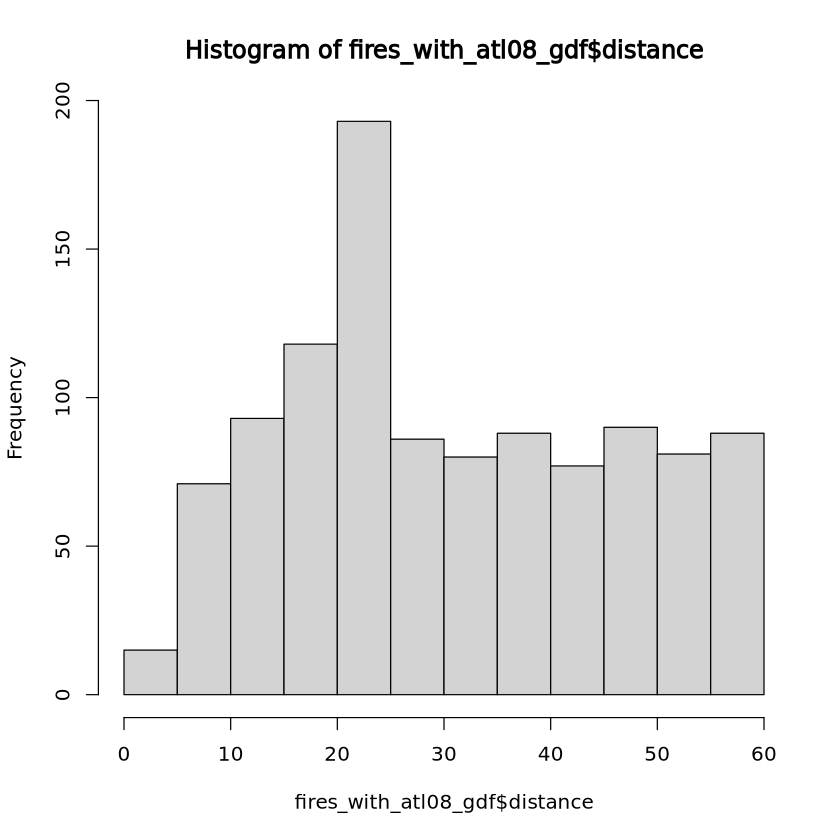

In [8]:
hist(fires_with_atl08_gdf$distance)

In [9]:
#head(fires_with_atl08_gdf[,grep( "extent" , names( fires_with_atl08_gdf ) )])

In [10]:
fires_with_atl08_gdf$diff_pre_post = fires_with_atl08_gdf$h_canopy_pre - fires_with_atl08_gdf$h_canopy_post

# Order by diff in height
#fires_with_atl08_gdf = fires_with_atl08_gdf[order(fires_with_atl08_gdf$diff_pre_post, decreasing = FALSE),]  
# Order by pre-fire height
fires_with_atl08_gdf = fires_with_atl08_gdf[order(fires_with_atl08_gdf$h_canopy_pre, decreasing = FALSE),]  

In [11]:
source('/projects/code/3dsi/boreal_map_functions.R') 

Warning message:
“package ‘fs’ was built under R version 4.3.3”

Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110




[1] "MAAP"
[1] "MAAP"


In [12]:
REP_DIST = 15

In [13]:
fires_with_atl08_gdf_SUB = fires_with_atl08_gdf %>% filter(distance < REP_DIST)

In [20]:
fires_with_atl08_gdf_SUB_QUEBEC = fires_with_atl08_gdf_SUB %>% st_crop(xmin = -80, xmax = -60, ymin = 45, ymax = 70)

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers
Reading layer `ABoVE_Study_Domain' from data source 
  `/projects/my-public-bucket/databank/arc/ABoVE_Study_Domain_Final/ABoVE_Study_Domain.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3398275 ymin: 997535.1 xmax: 623682.7 ymax: 4562705
Projected CRS: Canada_Albers_Equal_Area_Conic


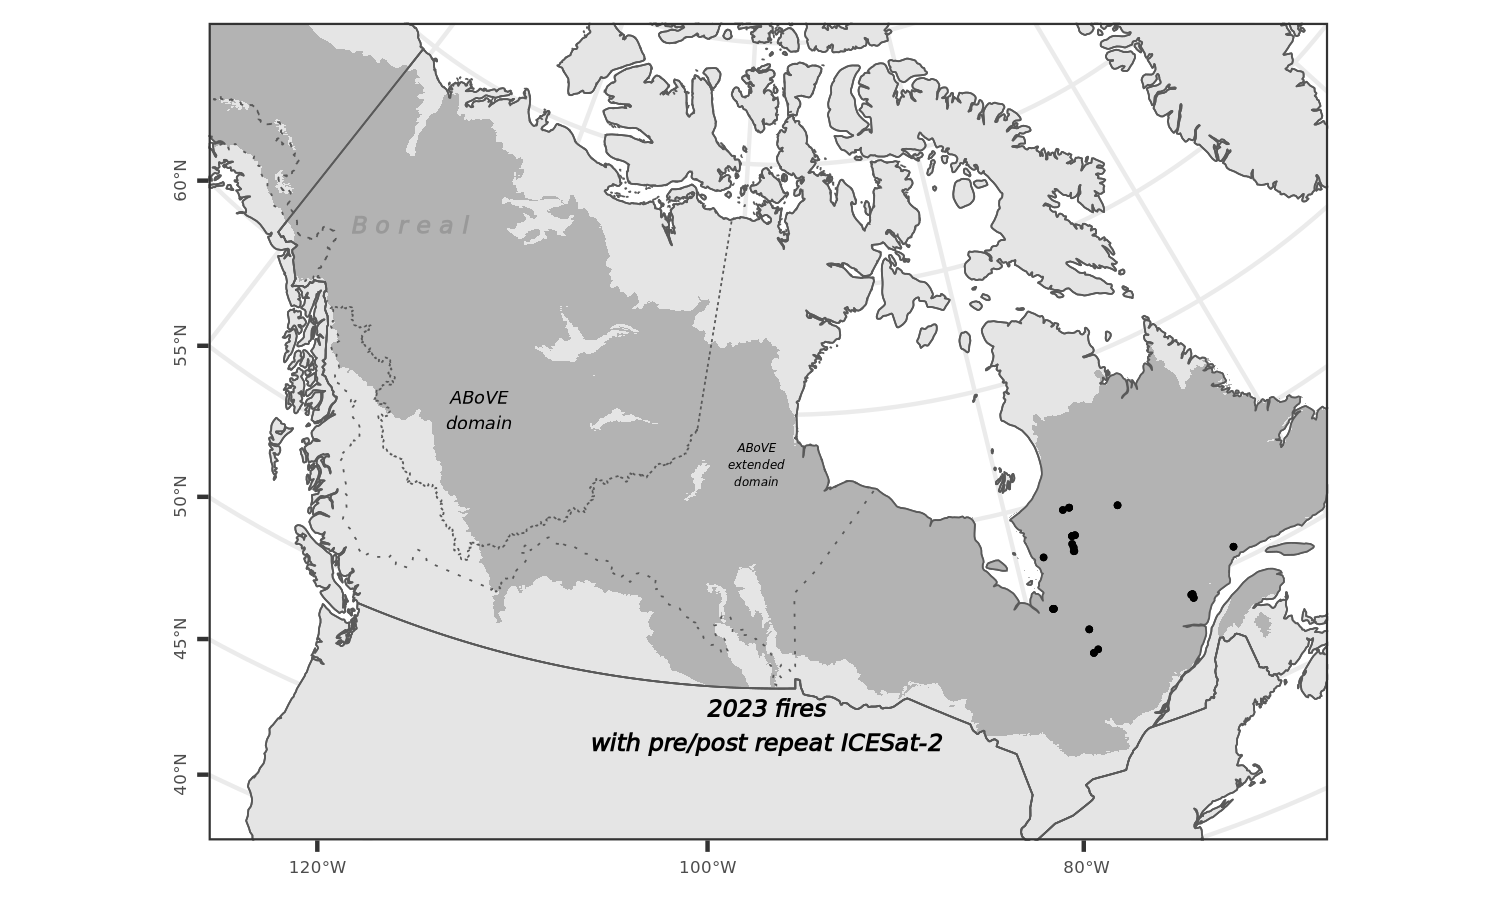

In [30]:
options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 300)


crs_wgs84 = "+proj=longlat +datum=WGS84 +ellps=WGS84 +towgs84=0,0,0,0,0,0,0 +no_defs"

# https://www.r-bloggers.com/2019/04/zooming-in-on-maps-with-sf-and-ggplot2/
disp_win_wgs84 <- st_sfc(st_point(c(-125, 37.5)), st_point(c(-35, 65)), crs = 4326)
disp_win_trans <- st_transform(disp_win_wgs84, crs = crs_canalb)
disp_win_coord <- st_coordinates(disp_win_trans)

  txt_wgs84 <- st_sfc(st_point(c(-132, 63.5)), st_point(c(-120, 58)), st_point(c(-98, 58)), st_point(c(-97, 47.5)), crs = 4326) #-121.5, 52.75
  txt_trans <- st_transform(txt_wgs84, crs = crs_canalb)
  txt_coord <- st_coordinates(txt_trans)

add_theme_custom = list(
        theme_bw(),
        theme(legend.position = c(0.9 ,0.9),
          legend.text=element_text(size=rel(1)),
          legend.background = element_blank(),
          legend.box.background = element_rect(colour = "black"),
          axis.title.x = element_blank(),
          axis.title.y = element_blank(),
          axis.text = element_text(size = 4),
          axis.text.y = element_text(angle=90, hjust = 0.5)
          )
  )

custom_map_above = list(
    coord_sf(xlim = disp_win_coord[,'X'], ylim = disp_win_coord[,'Y'], crs = crs_canalb, expand = F),
    #annotation_scale(location = "bl", width_hint = 0.15) ,
    annotate(geom = "text", x = txt_coord[,'X'], y = txt_coord[,'Y'], label = c("B o r e a l","ABoVE\ndomain","ABoVE\nextended\ndomain","2023 fires\nwith pre/post repeat ICESat-2"), 
             fontface = c("bold.italic", "italic", "italic","bold.italic"), color = c("grey60","black","black",'black'), size = c(2,1.5,1,2)) ,
    add_theme_custom
)

p_map_flightlines = do_map_above_boreal() +
    #geom_sf(data = st_as_sf(world) %>% filter(subregion == "Northern America") )+ #%>% st_transform(crs = crs_canalb) %>% st_crop(extent(sites))
    # geom_sf(data=fires_with_atl08_gdf_SUB %>% 
    #         st_transform(crs = crs_wgs84), 
    #         #aes(color=factor(tile_num),fill=factor(extent_id_pre)),
    #         size=0.65) +
    geom_sf(data = fires_with_atl08_gdf_SUB_QUEBEC  %>% st_transform(crs = crs_wgs84)  , size = 0.2, color='black')
    #geom_sf(data=disp_win_wgs84, size=15)+
    ##scale_color_manual(values = brewer.pal(11,"Set1"), name = "Campaign", guide=F)+
    ##scale_fill_manual(values = brewer.pal(11,"Set1"), name = 'Campaign')

p_map = p_map_flightlines + custom_map_above
p_map

### Questions based on plot below
1. Fire polygon id? What is 'extent_id_pre' and 'post'? Shouldnt each ATL08 pre/post fire repeat pair have the same fire poly id for pre- and post-fire?
 - each repeat pair should have a Fire polygon id
2. What is the deal with the height diffs that are negative? These show taller post fire heights by a lot!

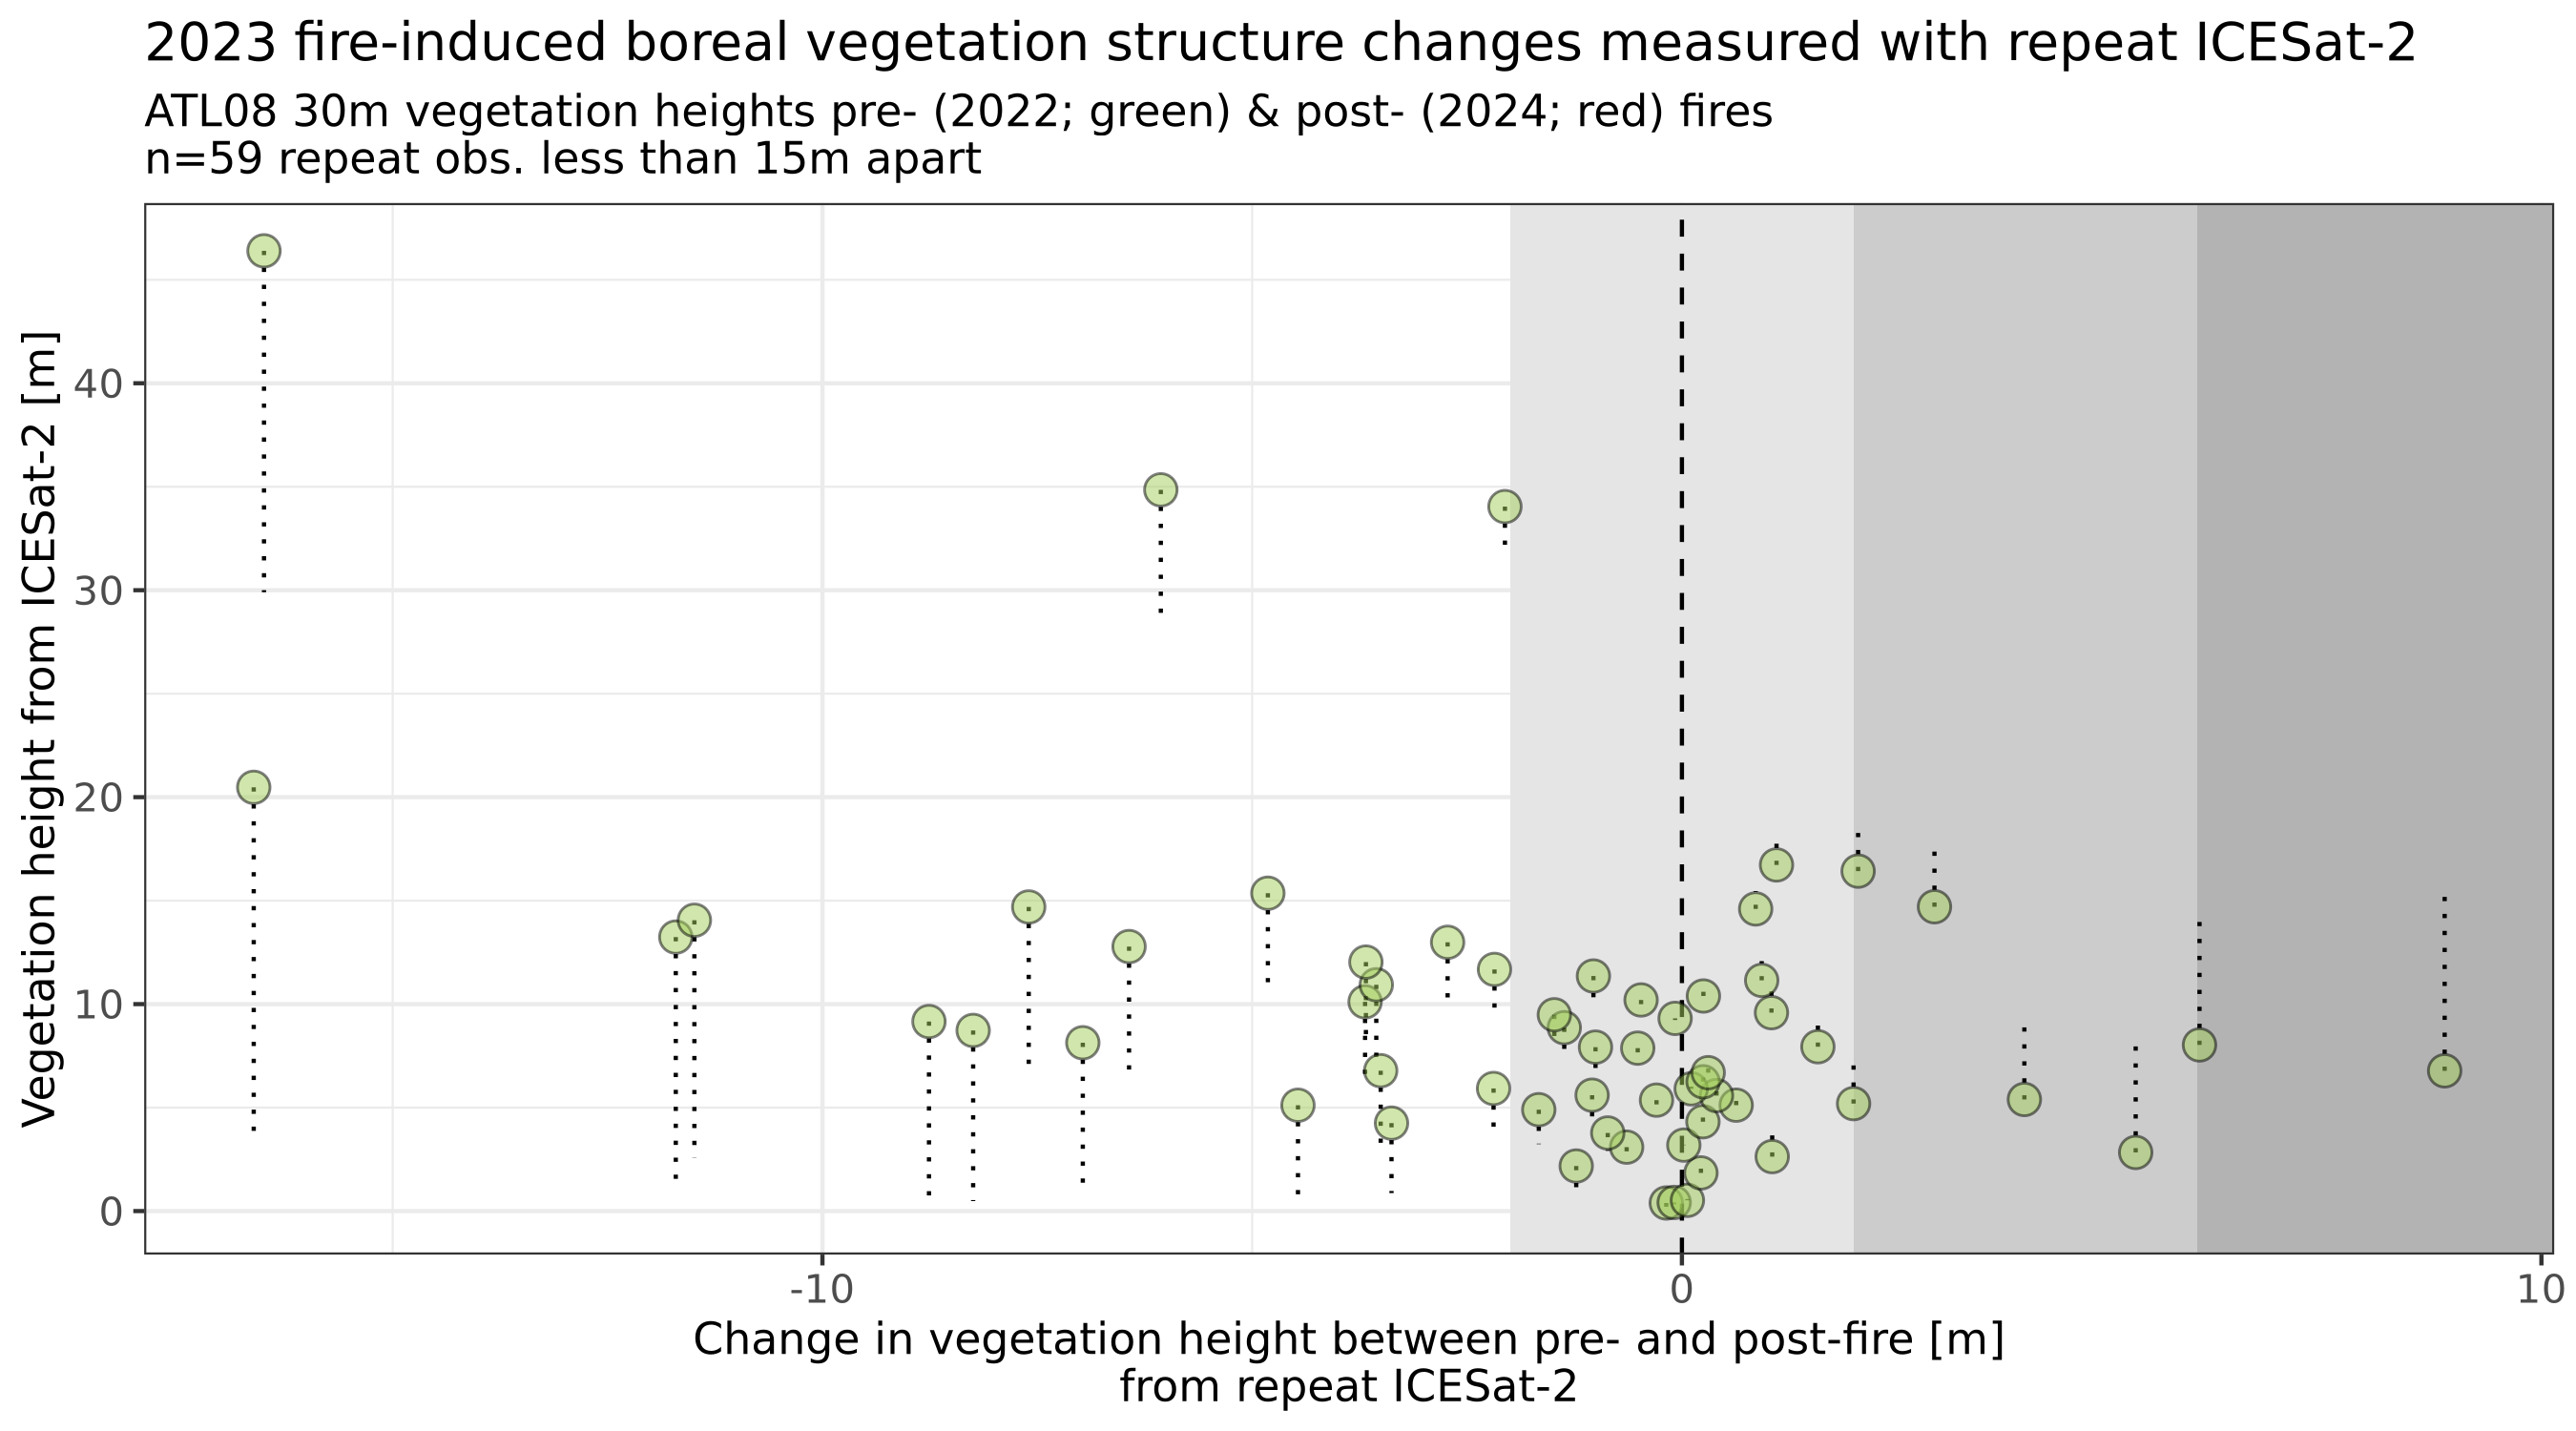

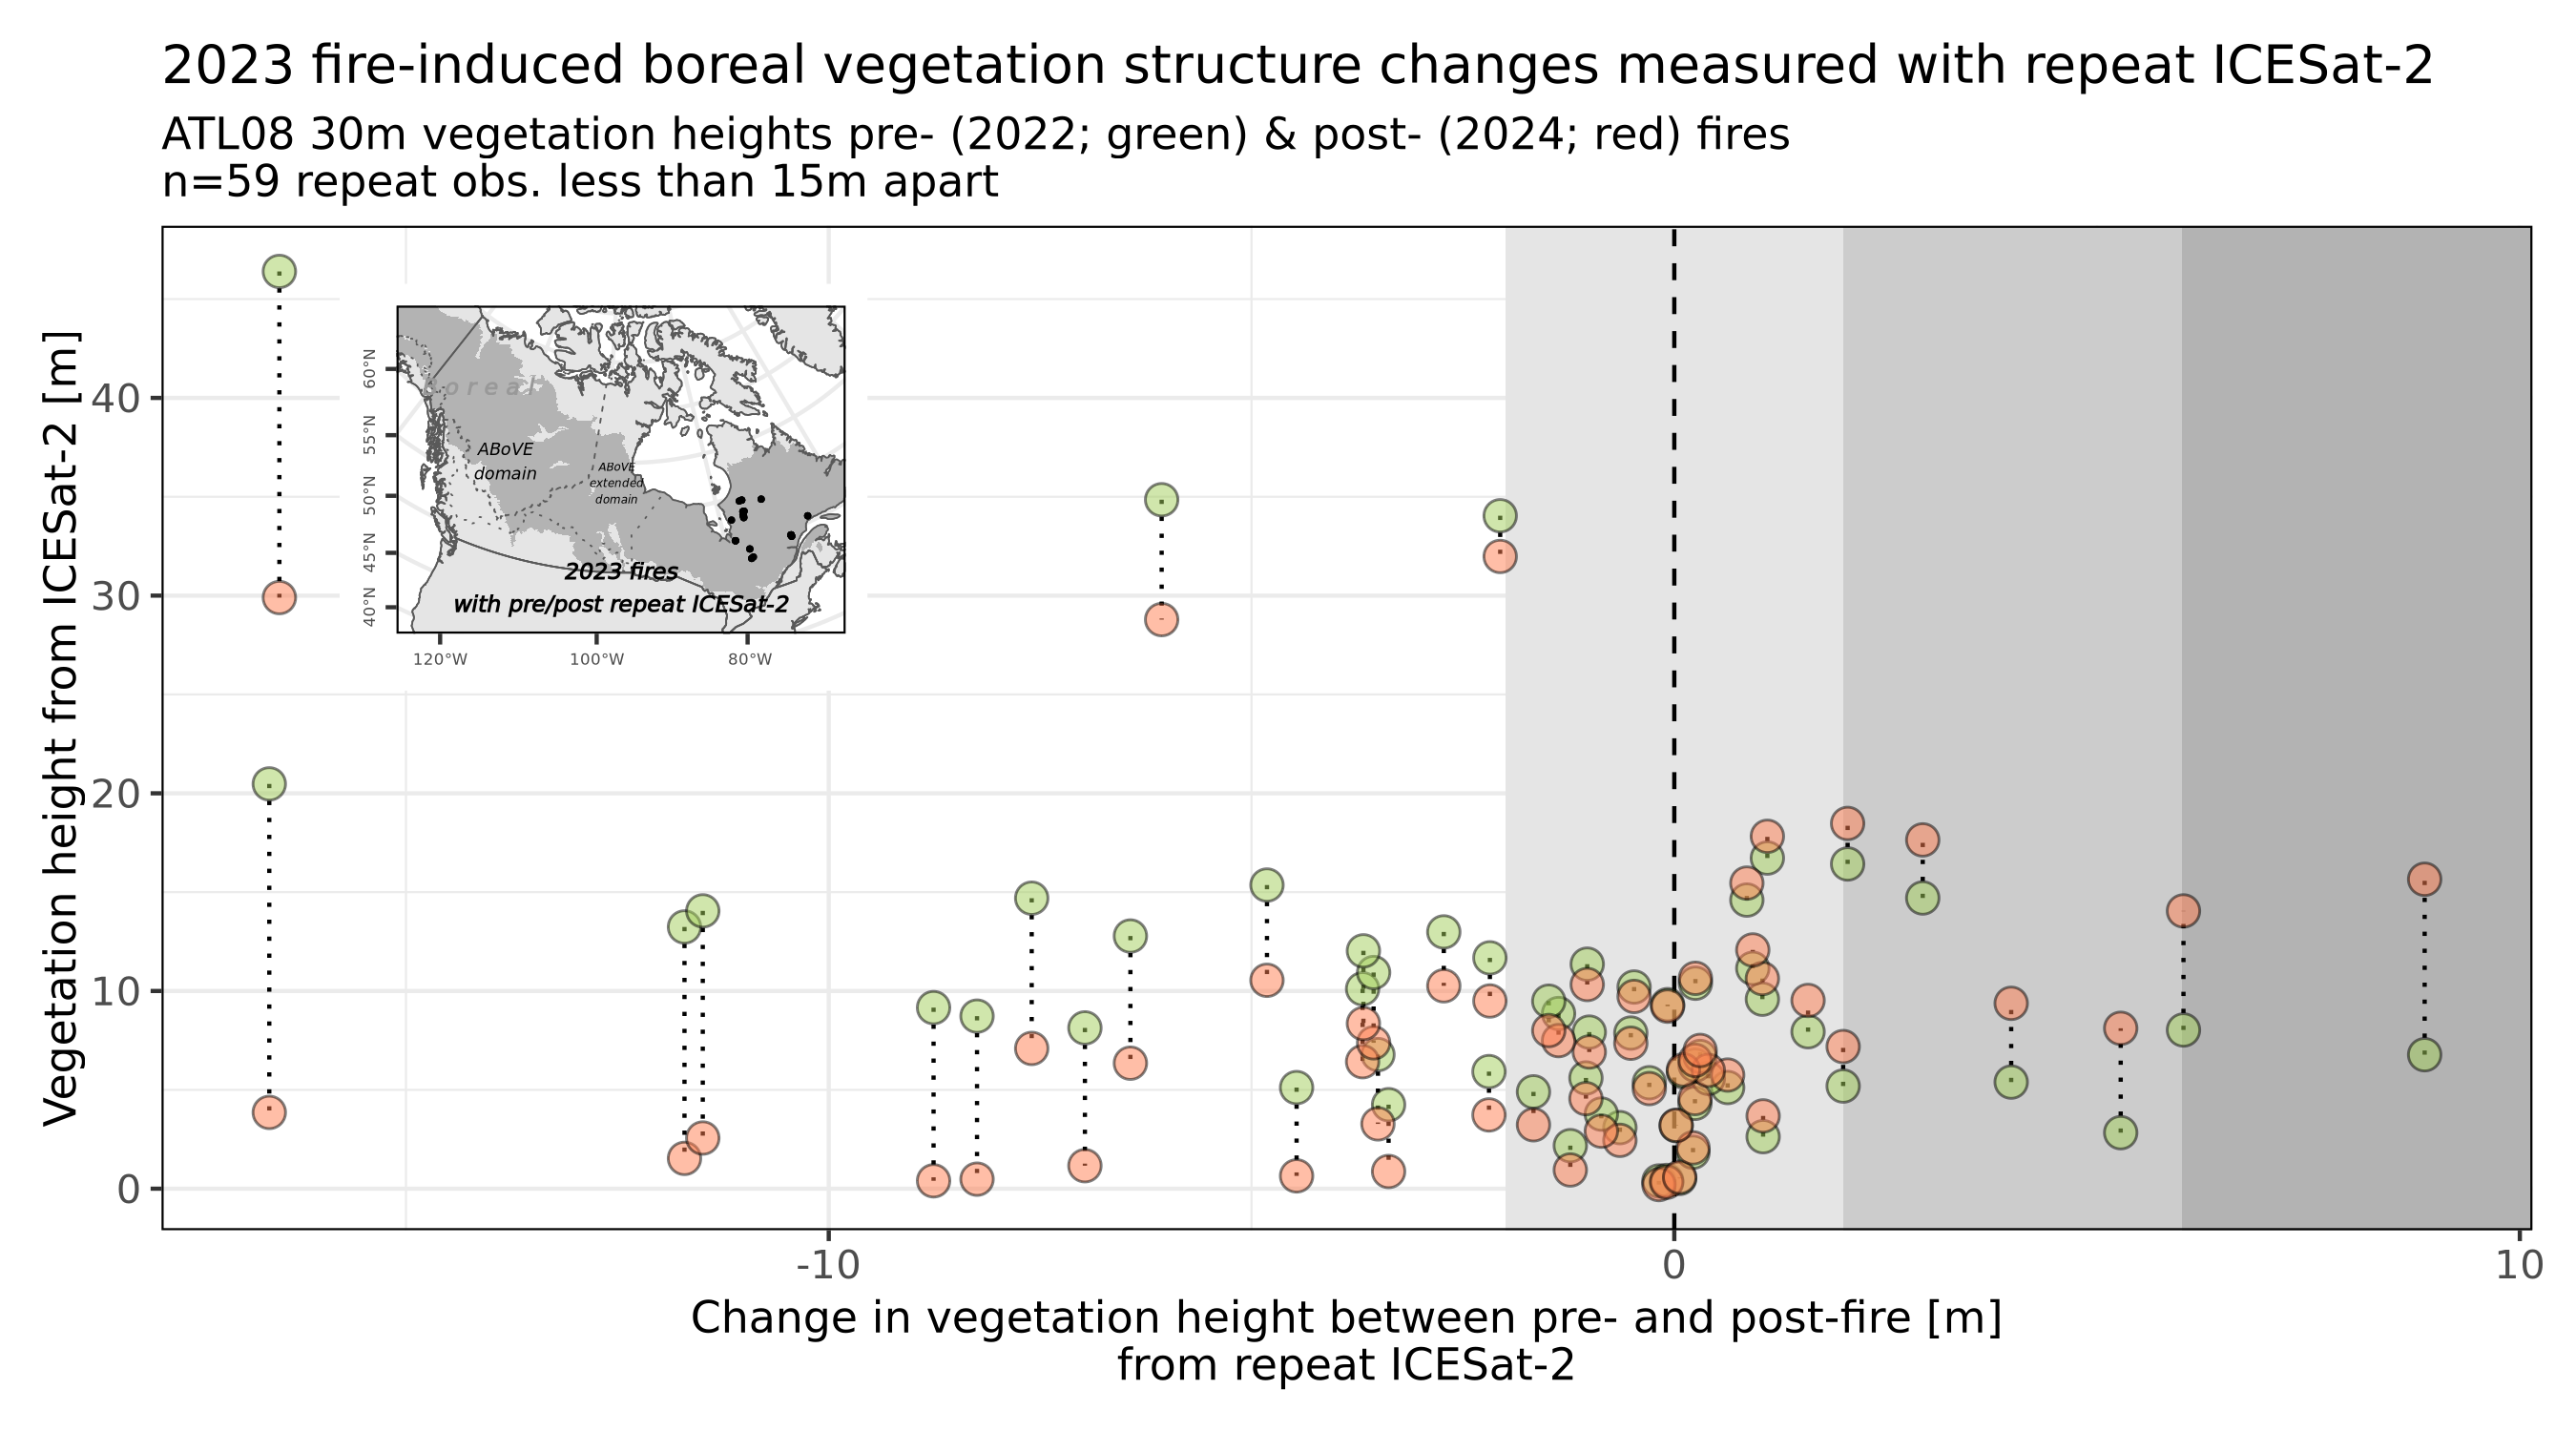

In [31]:
options(repr.plot.width = 9, repr.plot.height = 5, repr.plot.res = 300)

SZ = 3.5
SHAPE = 21
TEXT_ADJUST=-5

p_fires_pre = ggplot(fires_with_atl08_gdf_SUB_QUEBEC, aes(x=canopy_diff , group=factor(extent_id_pre)) ) +
    geom_rect(xmax=6, xmin=Inf, ymin=-Inf,ymax=Inf, fill='gray70')+
    geom_rect(xmax=2, xmin=6, ymin=-Inf,ymax=Inf, fill='gray80')+
    geom_rect(xmin=-2,xmax=2, ymin=-Inf,ymax=Inf, fill='gray90')+
    geom_rect(xmax=-Inf, xmin=-2, ymin=-Inf,ymax=Inf, fill='gray100', alpha=0)+
    # geom_text(x=12+TEXT_ADJUST, y=33, label="Unknown", hjust=0, vjust=1, size=SZ)+
    # geom_text(x=12+TEXT_ADJUST, y=29, label="height is larger\npost-fire", hjust=0, vjust=1, size=SZ-1)+
    # geom_text(x=7+TEXT_ADJUST, y=33, label="Low severity\n(ground fire)", hjust=0, vjust=1, size=SZ)+
    # geom_text(x=7+TEXT_ADJUST, y=29, label="results in burn of\nunderstory that\nlowered 'ground'\nelevation detected\nby ICESat-2?", hjust=0, vjust=1, size=SZ-1)+
    # geom_text(x=-10+TEXT_ADJUST, y=33, label="High severity\n(crown fire)", hjust=0, vjust=1, size=SZ)+
    # geom_text(x=-10+TEXT_ADJUST, y=29, label="results in small-to-large decreases in vegetation height", hjust=0, vjust=1, size=SZ-1)+ 
    geom_vline(xintercept=0, linetype='dashed')+
    geom_linerange(aes( ymin=h_canopy_pre, ymax=h_canopy_post), linetype='dotted') +
    geom_point(aes(y=h_canopy_pre), fill='darkolivegreen3', color='black', size=SZ, shape=SHAPE, alpha=0.5) +
    #geom_point(aes(y=h_canopy_post), fill='coral', color='black', size=SZ, shape=SHAPE, alpha=0.5) +
    theme_bw()+
    #scale_x_continuous(limits=c(-2,2)) +
    theme(axis.text=element_text(size=10))+
    labs(title="2023 fire-induced boreal vegetation structure changes measured with repeat ICESat-2",
         subtitle=paste0("ATL08 30m vegetation heights pre- (2022; green) & post- (2024; red) fires\nn=",dim(fires_with_atl08_gdf_SUB_QUEBEC)[1]," repeat obs. less than ",REP_DIST,"m apart"), 
         y='Vegetation height from ICESat-2 [m]', 
         x='Change in vegetation height between pre- and post-fire [m]\nfrom repeat ICESat-2'
        )
p_fires = p_fires_pre + geom_point(aes(y=h_canopy_post), fill='coral', color='black', size=SZ, shape=SHAPE, alpha=0.5)

p_fires_pre

#p_fires + inset_element(p_map, left = 0.675, bottom = 0.58, right = 0.975, top = 0.995) & theme(panel.border = element_rect(colour = "black", fill=NA))
p_fires + inset_element(align_to = 'plot', p_map, left = 0.05, bottom = 0.6, right = 0.4, top = 0.95, on_top = TRUE) & theme(panel.border = element_rect(colour = "black", fill=NA))


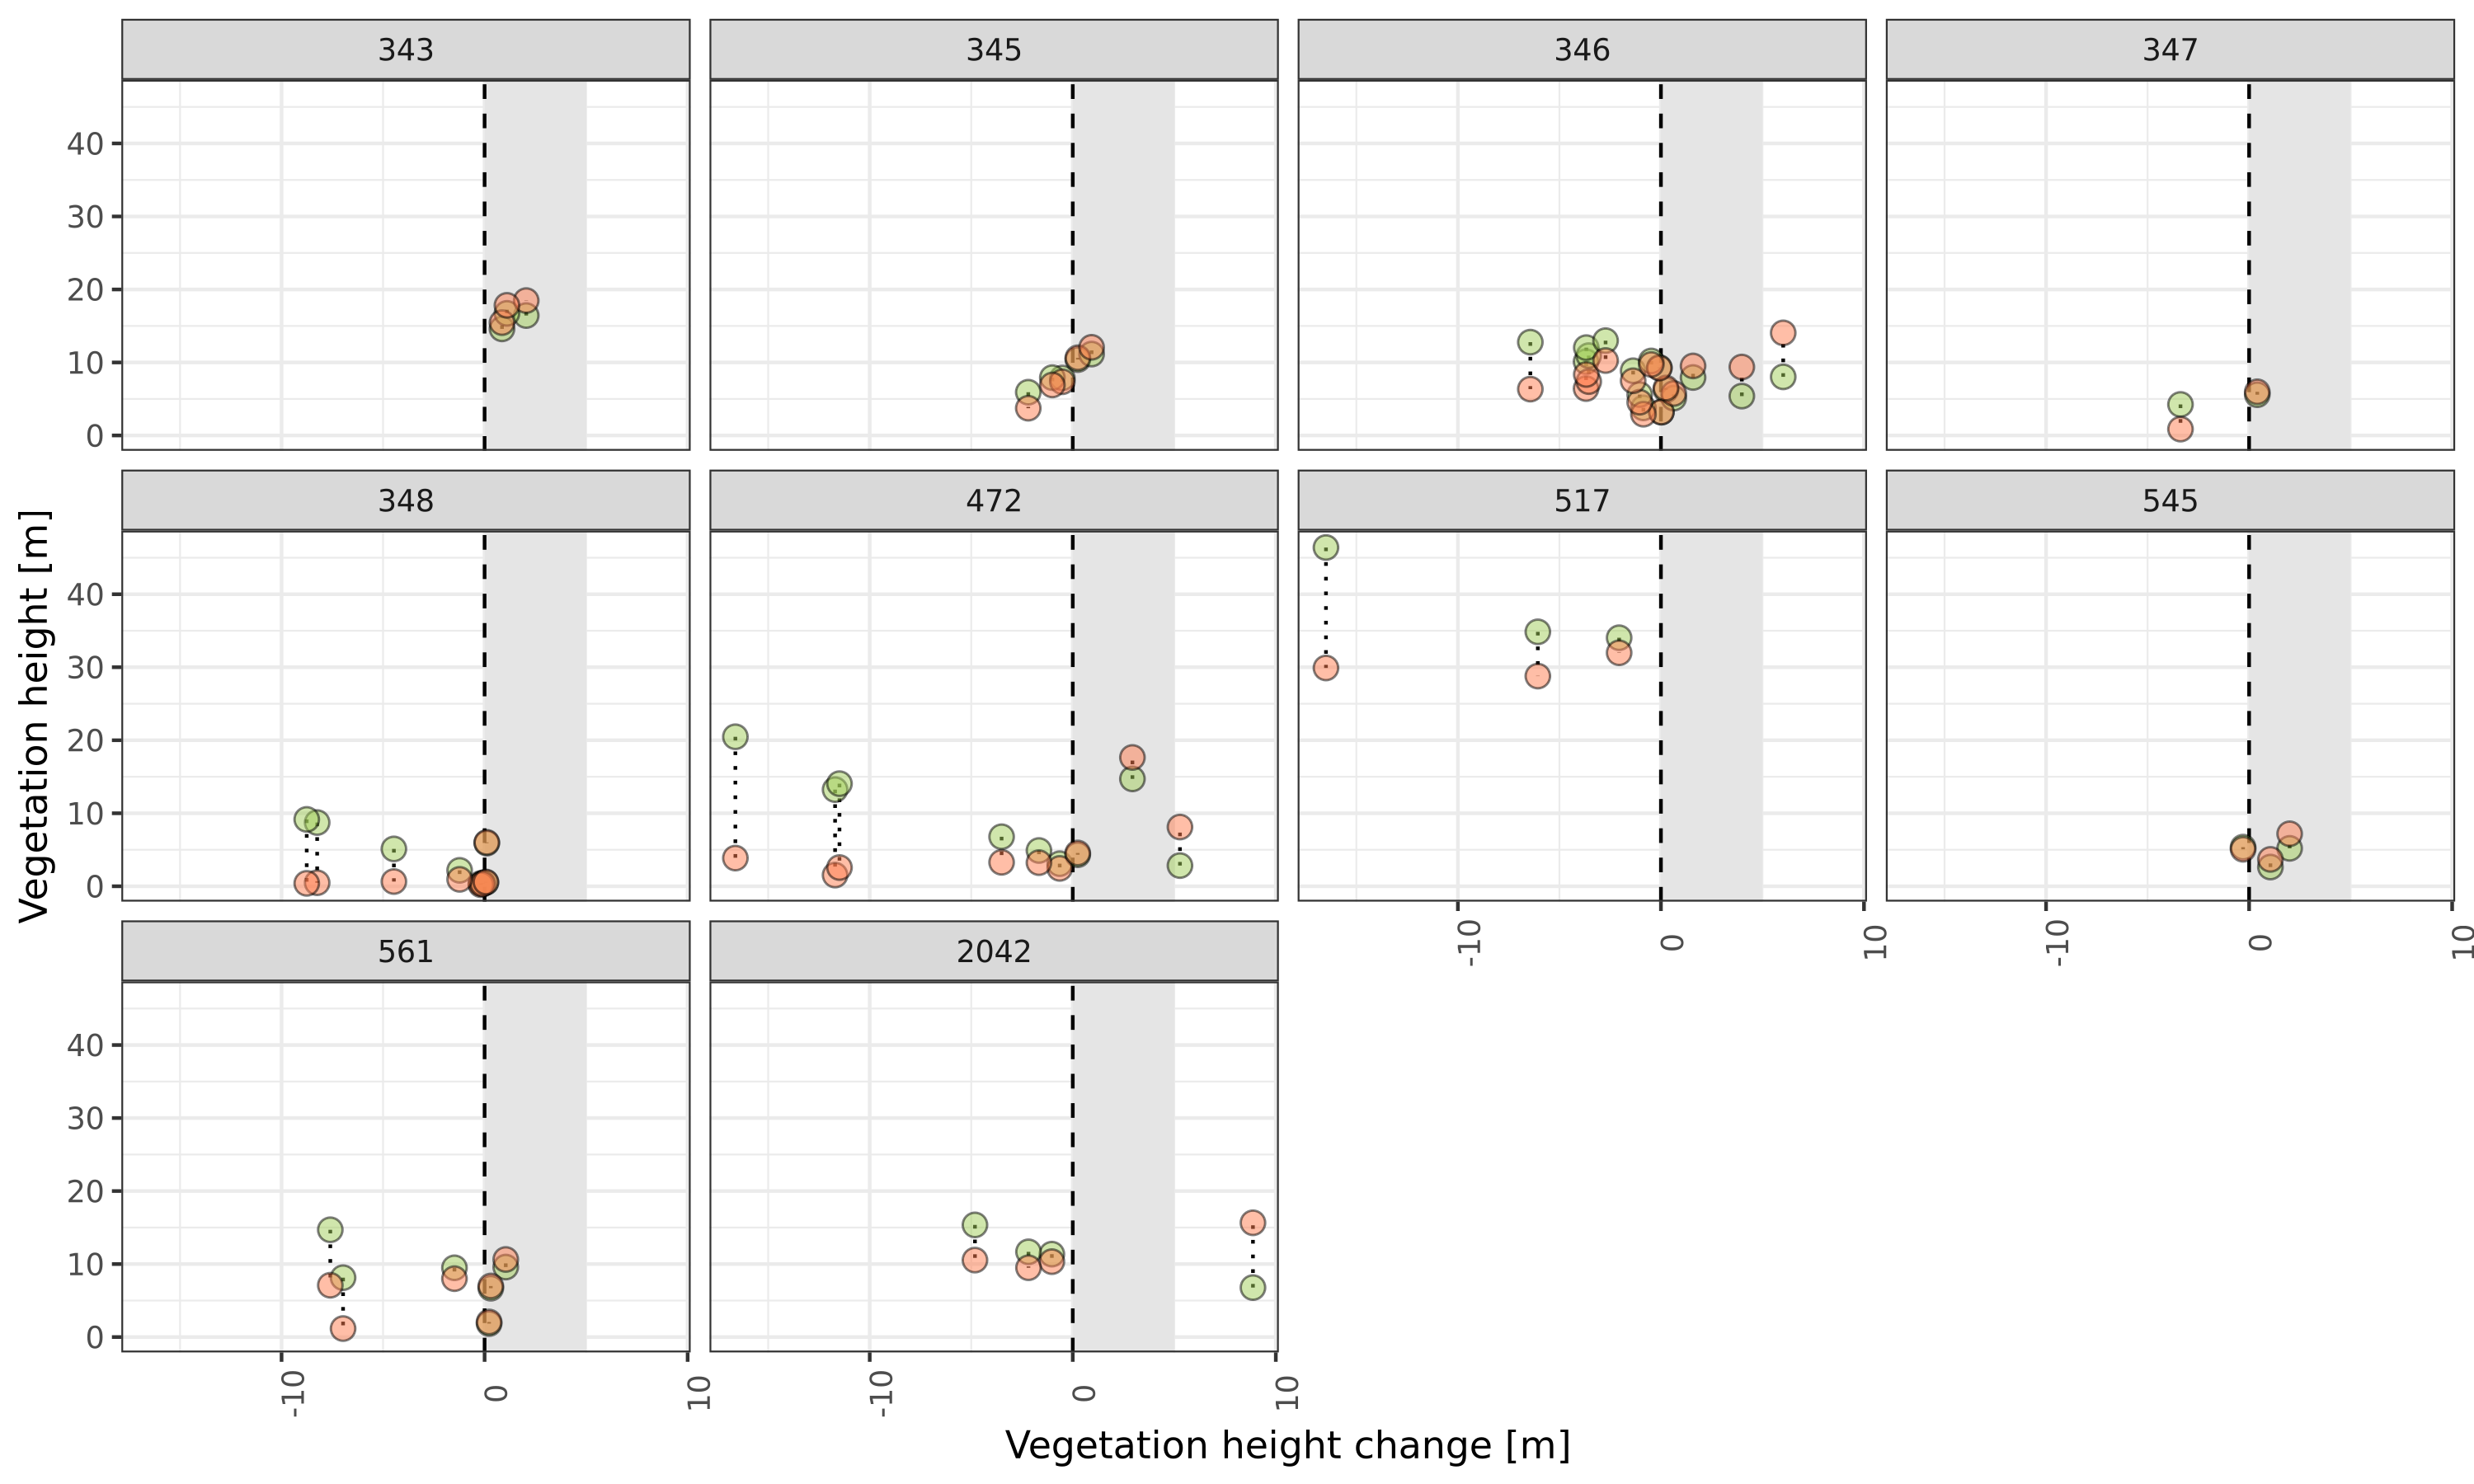

In [27]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)

SZ = 3
SHAPE = 21

ggplot(fires_with_atl08_gdf_SUB_QUEBEC
       , aes(x=canopy_diff , group=factor(NFIREID)) ) +
geom_rect(xmin=0,xmax=5, ymin=-Inf,ymax=Inf, fill='gray90')+
geom_vline(xintercept=0, linetype='dashed')+
geom_linerange(aes( ymin=h_canopy_pre, ymax=h_canopy_post), linetype='dotted') +
geom_point(aes(y=h_canopy_pre), fill='darkolivegreen3', color='black', size=SZ, shape=SHAPE, alpha=0.5) +
geom_point(aes(y=h_canopy_post), fill='coral', color='black', size=SZ, shape=SHAPE, alpha=0.5) +
theme_bw()+
facet_wrap(NFIREID~., ncol=4)+
theme(axis.text.x=element_text(angle=90))+
labs(y='Vegetation height [m]', x='Vegetation height change [m]')

In [76]:
df.m = melt(df[,c('extent_id_pre','segment_id_pre','h_canopy_pre','h_canopy_post','geom')], id.vars=c('extent_id_pre','segment_id_pre','geom'), meas.vars=c('h_canopy_pre','h_canopy_post'))